# Проект: отбор коров для молочного хозяйства «Вольный луг»

## Описание проекта

Молочное хозяйство «Вольный луг» планирует расширить поголовье и приобрести новых коров у ассоциации пастбищ «ЭкоФерма».

Фермер тщательно подходит к выбору животных и хочет снизить риски при покупке. Каждая новая корова должна соответствовать двум требованиям:

- давать не менее **6000 килограммов молока в год**;
- производить молоко, которое соответствует критериям фермера и оценивается как **вкусное**.

Для принятия объективного решения необходимо разработать две модели машинного обучения:

1. модель регрессии, прогнозирующую возможный годовой удой коровы;
2. модель классификации, определяющую вероятность получения вкусного молока.

На основании прогнозов необходимо отобрать коров, которые одновременно соответствуют обоим требованиям.

---

## Цель проекта

Разработать модели машинного обучения, позволяющие:

- спрогнозировать годовой удой коров;
- спрогнозировать вкус молока;
- оценить риски покупки;
- выбрать коров, подходящих фермеру по заданным критериям.

---

## Критерии отбора коров

Корова может быть рекомендована к покупке, если:

- прогнозируемый годовой удой составляет не менее **6000 кг**;
- молоко прогнозируется как **вкусное**.

---

# Описание данных

В проекте используются три датасета:

- `ferma_main.csv`;
- `ferma_dad.csv`;
- `cow_buy.csv`.

---

## Датасет `ferma_main.csv`

Датасет содержит информацию о текущем стаде фермера.

### Признаки

- `id` — уникальный идентификатор коровы;
- `Удой, кг` — масса молока, которую корова даёт за год;
- `ЭКЕ (Энергетическая кормовая единица)` — показатель питательности корма;
- `Сырой протеин, г` — содержание сырого протеина в корме;
- `СПО (Сахаро-протеиновое соотношение)` — отношение сахара к протеину в корме;
- `Порода` — порода коровы;
- `Тип пастбища` — тип местности, на которой паслась корова;
- `порода папы_быка` — порода отца коровы;
- `Жирность,%` — содержание жиров в молоке;
- `Белок,%` — содержание белков в молоке;
- `Вкус молока` — оценка вкуса молока по критериям фермера;
- `Возраст` — возрастная категория коровы.

### Группы признаков

**Характеристики коровы:**

- `id`;
- `Порода`;
- `порода папы_быка`;
- `Возраст`.

**Характеристики корма:**

- `ЭКЕ`;
- `Сырой протеин, г`;
- `СПО`.

**Характеристика пастбища:**

- `Тип пастбища`.

**Характеристики молока:**

- `Удой, кг`;
- `Жирность,%`;
- `Белок,%`;
- `Вкус молока`.

---

## Датасет `ferma_dad.csv`

Датасет содержит информацию об имени отца каждой коровы из текущего стада.

### Признаки

- `id` — уникальный идентификатор коровы;
- `Имя Папы` — имя отца коровы.

Датасет будет объединён с `ferma_main.csv` по идентификатору `id`.

---

## Датасет `cow_buy.csv`

Датасет содержит информацию о коровах «ЭкоФермы», которых фермер рассматривает для покупки.

### Признаки

- `Порода` — порода коровы;
- `Тип пастбища` — тип пастбища;
- `порода папы_быка` — порода отца коровы;
- `Имя_папы` — имя отца коровы;
- `Текущая_жирность,%` — жирность молока на момент продажи;
- `Текущий_уровень_белок,%` — содержание белка в молоке на момент продажи;
- `Возраст` — возрастная категория коровы.

### Особенности датасета `cow_buy.csv`

Данные в `ferma_main.csv` и `cow_buy.csv` похожи, однако датасет с коровами для покупки имеет несколько особенностей:

- жирность и содержание белка указаны на момент продажи, когда коровы получали корм от «ЭкоФермы»;
- отсутствуют характеристики корма:
  - `ЭКЕ`;
  - `Сырой протеин, г`;
  - `СПО`;
- для новых коров планируется увеличить среднее значение каждого параметра корма на **5%**;
- отсутствуют целевые признаки:
  - `Удой, кг`;
  - `Вкус молока`.

Эти признаки необходимо спрогнозировать с помощью моделей машинного обучения.

---

# План выполнения проекта

## Шаг 1. Загрузка и изучение данных

На первом этапе необходимо:

- импортировать необходимые библиотеки;
- загрузить датасеты в датафреймы `pandas`;
- вывести первые строки каждого датасета;
- изучить размеры таблиц;
- проверить названия столбцов;
- изучить общую информацию о данных;
- сравнить фактические признаки с описанием проекта;
- при необходимости привести названия столбцов к единому стилю.

По результатам этапа необходимо сделать краткий вывод о структуре и качестве исходных данных.

---

## Шаг 2. Предобработка данных

На этапе предобработки необходимо проверить:

- наличие пропущенных значений;
- наличие явных дубликатов;
- наличие неявных дубликатов в категориальных признаках;
- корректность типов данных;
- корректность значений признаков;
- единообразие названий категорий.

При обнаружении проблем необходимо:

- обработать пропуски;
- удалить или исправить дубликаты;
- изменить типы данных;
- исправить некорректные значения;
- привести категориальные значения к единому формату.

По окончании этапа необходимо проверить результат предобработки и сделать вывод о готовности данных к анализу.

---

## Шаг 3. Исследовательский анализ данных

На этом этапе необходимо провести статистический анализ всех признаков.

Для количественных признаков следует:

- рассчитать описательные статистики;
- изучить среднее значение, медиану, минимум и максимум;
- построить гистограммы;
- построить диаграммы размаха;
- проверить наличие выбросов;
- изучить форму распределений.

Для категориальных признаков следует:

- определить количество уникальных значений;
- рассчитать частоты категорий;
- построить столбчатые диаграммы;
- проверить баланс категорий.

Необходимо проанализировать:

- необычные значения;
- выбросы;
- асимметричные распределения;
- редкие категории;
- дисбаланс целевого признака `Вкус молока`.

По результатам анализа следует сделать выводы о качестве данных и определить, какие преобразования потребуются перед построением моделей.

---

## Шаг 4. Корреляционный анализ признаков

На этом этапе необходимо изучить взаимосвязи между признаками датасета `ferma_main.csv`.

Необходимо:

- рассчитать коэффициенты корреляции между количественными признаками;
- построить матрицу корреляций;
- визуализировать матрицу корреляций;
- построить диаграммы рассеяния между целевым признаком `Удой, кг` и количественными входными признаками;
- учитывать значения категориальных признаков при построении диаграмм;
- изучить взаимосвязи отдельно для различных пород, типов пастбища и возрастных групп.

Особое внимание необходимо уделить следующим вопросам:

- какой тип взаимосвязи наблюдается между удоем и входными признаками;
- присутствуют ли линейные зависимости;
- присутствуют ли нелинейные зависимости;
- необходимо ли создавать дополнительные признаки;
- наблюдается ли мультиколлинеарность между входными признаками;
- какие признаки целесообразно использовать при построении линейной регрессии.

По результатам анализа необходимо сформировать набор признаков для первой модели регрессии и определить направления улучшения следующих моделей.

---

## Шаг 5. Задача регрессии

Цель данного этапа — построить модель, прогнозирующую годовой удой коровы.

Целевой признак:

- `Удой, кг`.

В рамках проекта необходимо обучить три модели линейной регрессии.

---

### Шаг 5.1. Первая модель линейной регрессии

Для построения первой модели необходимо:

- выбрать признаки, подходящие для прогнозирования удоя;
- аргументировать выбор признаков;
- учитывать не только корреляцию, но и причинно-следственную связь признаков с удоем;
- разделить данные на обучающую и тестовую выборки;
- определить количественные и категориальные признаки;
- закодировать категориальные признаки с помощью `OneHotEncoder`;
- масштабировать количественные признаки с помощью `StandardScaler`;
- собрать предобработку и модель в единый пайплайн;
- обучить модель `LinearRegression`;
- получить прогноз на тестовой выборке.

Качество модели необходимо оценить с помощью:

- коэффициента детерминации `R²`;
- средней абсолютной ошибки `MAE`;
- средней квадратичной ошибки `MSE`;
- корня из средней квадратичной ошибки `RMSE`.

Также необходимо провести анализ остатков:

- рассчитать остатки модели;
- построить распределение остатков;
- построить график остатков относительно прогнозов;
- проверить, сосредоточены ли остатки около нуля;
- проверить наличие систематических закономерностей.

По результатам необходимо сделать вывод о качестве первой модели и определить, требуются ли дополнительные преобразования признаков.

---

### Шаг 5.2. Вторая модель линейной регрессии

Вторая модель должна учитывать нелинейные связи между признаками и целевым признаком.

Для этого необходимо:

- изучить диаграммы рассеяния;
- определить нелинейные зависимости;
- преобразовать признак `СПО` в бинарный категориальный признак с использованием границы между двумя группами значений;
- создать новый признак, содержащий квадрат значения `ЭКЕ`;
- при необходимости исключить исходные признаки, которые после преобразования становятся избыточными;
- повторно разделить признаки на количественные и категориальные;
- выполнить кодирование и масштабирование;
- обучить вторую модель `LinearRegression`;
- получить прогнозы;
- рассчитать `R²`, `MAE`, `MSE` и `RMSE`;
- проанализировать остатки модели.

По результатам необходимо сравнить вторую модель с первой и определить, улучшили ли дополнительные признаки качество прогнозирования.

---

### Шаг 5.3. Третья модель линейной регрессии

Для построения третьей модели необходимо добавить информацию об имени отца коровы.

Необходимо:

- объединить датасеты `ferma_main.csv` и `ferma_dad.csv` по признаку `id`;
- проверить корректность объединения;
- добавить признак `Имя Папы`;
- сохранить преобразования, использованные во второй модели;
- подготовить количественные и категориальные признаки;
- выполнить кодирование и масштабирование;
- обучить третью модель `LinearRegression`;
- получить прогнозы;
- рассчитать `R²`, `MAE`, `MSE` и `RMSE`;
- провести анализ остатков.

Необходимо определить, помогло ли добавление информации об имени отца улучшить прогноз удоя.

---

### Шаг 5.4. Сравнение моделей регрессии

Необходимо сравнить три модели по следующим параметрам:

- `R²`;
- `MAE`;
- `MSE`;
- `RMSE`;
- распределение остатков;
- наличие систематических ошибок;
- устойчивость прогнозов.

Результаты сравнения следует представить в виде таблицы.

После сравнения необходимо выбрать лучшую модель регрессии.

---

### Шаг 5.5. Доверительный интервал прогноза

Для лучшей модели необходимо оценить неопределённость прогнозов.

Для этого следует:

- получить прогнозы модели на обучающей выборке;
- рассчитать ошибки прогнозов;
- определить нижний и верхний квантили ошибок;
- сформировать доверительный интервал для прогнозируемого удоя.

Доверительный интервал необходимо учитывать при окончательном выборе коров, поскольку прогноз около 6000 кг может быть связан с высоким риском.

---

### Шаг 5.6. Прогноз удоя коров для покупки

Для применения лучшей модели к датасету `cow_buy.csv` необходимо добавить отсутствующие характеристики корма.

Следует:

- рассчитать среднее значение `ЭКЕ` в текущем стаде;
- рассчитать среднее значение `Сырой протеин, г`;
- рассчитать среднее значение `СПО`;
- увеличить каждое среднее значение на **5%**;
- добавить полученные значения в `cow_buy.csv`;
- привести названия признаков к формату обучающего датасета;
- создать все дополнительные признаки, использованные лучшей моделью;
- выполнить такую же предобработку, как для обучающих данных;
- получить прогноз годового удоя;
- добавить прогнозы в датафрейм с коровами для покупки;
- при необходимости добавить границы доверительного интервала.

---

## Шаг 6. Задача классификации

Цель данного этапа — построить модель, прогнозирующую вкус молока.

Целевой признак:

- `Вкус молока`.

Для решения задачи необходимо использовать модель `LogisticRegression`.

---

### Шаг 6.1. Подготовка данных для классификации

Необходимо:

- определить признаки, которые могут влиять на вкус молока;
- исключить идентификатор `id`;
- при необходимости добавить или преобразовать признаки;
- разделить данные на обучающую и тестовую выборки;
- учесть соотношение классов;
- определить количественные и категориальные признаки;
- закодировать категориальные признаки с помощью `OneHotEncoder`;
- масштабировать количественные признаки с помощью `StandardScaler`.

При разделении данных следует использовать стратификацию по целевому признаку.

---

### Шаг 6.2. Обучение модели логистической регрессии

Необходимо:

- создать пайплайн предобработки;
- добавить модель `LogisticRegression`;
- обучить модель на обучающей выборке;
- получить прогнозы классов;
- получить прогнозируемые вероятности принадлежности к классу «вкусно».

---

### Шаг 6.3. Оценка качества классификации

Качество модели необходимо оценить с помощью следующих метрик:

- `accuracy`;
- `precision`;
- `recall`.

Также необходимо:

- построить матрицу ошибок;
- определить количество истинно положительных прогнозов;
- определить количество истинно отрицательных прогнозов;
- определить количество ложноположительных прогнозов;
- определить количество ложноотрицательных прогнозов.

---

### Шаг 6.4. Анализ ошибок модели

Необходимо определить, какая ошибка является наиболее критичной для фермера.

Положительным классом считается вкусное молоко.

Следует проанализировать:

- ошибку первого рода — модель прогнозирует вкусное молоко, хотя фактически оно невкусное;
- ошибку второго рода — модель прогнозирует невкусное молоко, хотя фактически оно вкусное.

Для фермера наиболее опасна ситуация, когда модель рекомендует к покупке корову, но её молоко фактически оказывается невкусным.

Поэтому особое внимание необходимо уделить показателю `precision` положительного класса.

---

### Шаг 6.5. Изменение порога классификации

Стандартный порог классификации равен `0.5`.

Для снижения критичной ошибки необходимо:

- получить вероятности положительного класса;
- проверить несколько значений порога;
- рассчитать `precision` и `recall` для каждого порога;
- выбрать порог, при котором критичная ошибка сводится к нулю или минимальному значению;
- повторно построить матрицу ошибок;
- сравнить метрики до и после изменения порога.

Необходимо объяснить:

- какое значение порога было выбрано;
- почему выбран именно этот порог;
- как изменились `precision` и `recall`;
- какое влияние изменение порога оказывает на количество рекомендуемых коров.

---

### Шаг 6.6. Прогноз вкуса молока коров для покупки

Для датасета `cow_buy.csv` необходимо:

- привести признаки к формату обучающего набора;
- добавить недостающие характеристики корма;
- создать дополнительные признаки, использованные при обучении;
- выполнить аналогичную предобработку;
- получить вероятность вкусного молока;
- применить выбранный порог классификации;
- получить итоговый прогноз вкуса молока;
- добавить результаты в датафрейм с коровами для покупки.

---

## Шаг 7. Итоговый отбор коров и выводы

На заключительном этапе необходимо объединить результаты регрессионной и классификационной моделей.

В датафрейм `cow_buy.csv` необходимо добавить:

- прогнозируемый годовой удой;
- нижнюю границу прогноза удоя;
- верхнюю границу прогноза удоя;
- вероятность вкусного молока;
- прогнозируемый класс вкуса молока.

После этого необходимо отобрать коров, которые одновременно удовлетворяют требованиям:

- прогнозируемый удой составляет не менее **6000 кг в год**;
- молоко прогнозируется как вкусное.

Для более осторожной стратегии можно использовать нижнюю границу доверительного интервала и выбирать только тех коров, у которых она также превышает 6000 кг.

---

## Итоговые вопросы проекта

В итоговом выводе необходимо ответить на следующие вопросы:

- сколько коров фермер может приобрести с минимальным риском;
- почему именно эти коровы рекомендованы;
- какие риски остаются даже после применения моделей;
- насколько качественно модель регрессии прогнозирует удой;
- насколько качественно модель классификации прогнозирует вкус молока;
- какие способы улучшения модели регрессии были использованы;
- помогло ли добавление нелинейных признаков;
- помогло ли добавление имени отца коровы;
- возможно ли дополнительно улучшить модель регрессии;
- какие метрики классификации наиболее важны при оценке рисков;
- почему одного показателя `accuracy` недостаточно;
- как выбранный порог классификации влияет на риск покупки.

---

# Общий вывод

В общем выводе необходимо кратко описать:

- результаты исследовательского анализа;
- качество трёх моделей линейной регрессии;
- выбор лучшей модели регрессии;
- качество модели логистической регрессии;
- выбранный порог классификации;
- количество коров, рекомендованных к покупке;
- ограничения построенных моделей;
- практические рекомендации фермеру.

## Шаг 1. Загрузка и изучение данных

In [963]:
from tokenize import endpats

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import alpha
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (r2_score, mean_squared_error,
                             mean_absolute_error, root_mean_squared_error, accuracy_score, recall_score, precision_score, confusion_matrix)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

In [964]:
try:
    farm = pd.read_csv("https://code.s3.yandex.net/datasets/ferma_main.csv", sep=';')
    dad = pd.read_csv("https://code.s3.yandex.net/datasets/ferma_dad.csv", sep=';')
    buy = pd.read_csv("https://code.s3.yandex.net/datasets/cow_buy.csv", sep=';')
    print("Данные успешно загружены!")
except FileNotFoundError:
    print("Ошибка: один или несколько файлов не найдены.")
except Exception as e:
    print(f"Произошла ошибка: {e}")

Данные успешно загружены!


In [965]:
farm.columns = farm.columns.str.strip().str.lower()
dad.columns = dad.columns.str.strip().str.lower()
buy.columns = buy.columns.str.strip().str.lower()

In [966]:
display(farm.info())
display(farm.head())
display(dad.info())
display(dad.head())
display(buy.info())
display(buy.head())

<class 'pandas.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 12 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   id                                     634 non-null    int64
 1   удой, кг                               634 non-null    int64
 2   эке (энергетическая кормовая единица)  634 non-null    str  
 3   сырой протеин, г                       634 non-null    int64
 4   спо (сахаро-протеиновое соотношение)   634 non-null    str  
 5   порода                                 634 non-null    str  
 6   тип пастбища                           634 non-null    str  
 7   порода папы_быка                       634 non-null    str  
 8   жирность,%                             634 non-null    str  
 9   белок,%                                634 non-null    str  
 10  вкус молока                            634 non-null    str  
 11  возраст                                634 

None

,id,"удой, кг",эке (энергетическая кормовая единица),"сырой протеин, г",спо (сахаро-протеиновое соотношение),порода,тип пастбища,порода папы_быка,"жирность,%","белок,%",вкус молока,возраст
0,1,5863,"14,2",1743,"0,89",Вис Бик Айдиал,Равнинное,Айдиал,"3,58","3,076",вкусно,более_2_лет
1,2,5529,"12,8",2138,"0,89",Вис Бик Айдиал,Равнинные,Соверин,"3,54","3,079",вкусно,менее_2_лет
2,3,5810,14,1854,"0,885",РефлешнСоверинг,Холмистое,Соверин,"3,59","3,074",не вкусно,более_2_лет
3,4,5895,"12,4",2012,"0,885",РефлешнСоверинг,Холмистое,Айдиал,"3,4","3,075",не вкусно,более_2_лет
4,5,5302,"12,8",1675,"0,885",Вис Бик Айдиал,Равнинные,Соверин,"3,73","3,073",вкусно,менее_2_лет


<class 'pandas.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        629 non-null    int64
 1   имя папы  629 non-null    str  
dtypes: int64(1), str(1)
memory usage: 10.0 KB


None

,id,имя папы
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин


<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   порода                   20 non-null     str  
 1   тип пастбища             20 non-null     str  
 2   порода папы_быка         20 non-null     str  
 3   имя_папы                 20 non-null     str  
 4   текущая_жирность,%       20 non-null     str  
 5   текущий_уровень_белок,%  20 non-null     str  
 6   возраст                  20 non-null     str  
dtypes: str(7)
memory usage: 1.2 KB


None

,порода,тип пастбища,порода папы_быка,имя_папы,"текущая_жирность,%","текущий_уровень_белок,%",возраст
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,"3,58","3,076",более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,"3,54","3,081",менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,"3,4","3,061",более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,"3,64","3,074",более_2_лет


#### Данные загружены, все столбцы были приведены к нижнему регистру

## Шаг 2. Предобработка данных
#### Переименуем столбцы и изменим типы данных

In [967]:
farm.rename(columns={'эке (энергетическая кормовая единица)':'эке', 'спо (сахаро-протеиновое соотношение)': 'спо', 'порода папы_быка' : 'порода папы быка'}, inplace=True)
buy.rename(columns={'порода папы_быка': 'порода папы быка', 'имя_папы': 'имя папы'}, inplace=True)

farm['эке'] = farm['эке'].str.replace(',', '.').astype('float')
farm['спо'] = farm['спо'].str.replace(',', '.').astype('float')
farm['жирность,%'] = farm['жирность,%'].str.replace(',', '.').astype('float')
farm['белок,%'] = farm['белок,%'].str.replace(',', '.').astype('float')

buy['текущая_жирность,%'] = buy['текущая_жирность,%'].str.replace(',', '.').astype('float')
buy['текущий_уровень_белок,%'] = buy['текущий_уровень_белок,%'].str.replace(',', '.').astype('float')

#### Переименовали столбцы, изменили типы данных

In [968]:
print('Количество явных дубликатов:')
print(f'Данные о стаде фермера: {farm.duplicated().sum()}')
print(f'Имена пап коров: {dad.duplicated().sum()}')
print(f'Коровы ЭкоФермы: {buy.duplicated().sum()}')

Количество явных дубликатов:
Данные о стаде фермера: 5
Имена пап коров: 0
Коровы ЭкоФермы: 4


In [969]:
print('До исправления farm')
print(farm.nunique())
print(farm['порода'].unique())
print(farm['тип пастбища'].unique())
print(farm['порода папы быка'].unique())
print(farm['вкус молока'].unique())
print(farm['возраст'].unique())

farm['тип пастбища'] = farm['тип пастбища'].replace('Равнинные','Равнинное')
farm['порода папы быка'] = farm['порода папы быка'].replace('Айдиалл','Айдиал')
print("\nПосле исправления farm")
print(farm['тип пастбища'].unique())
print(farm['порода папы быка'].unique())

print('\nДо исправления cow')
print(buy.nunique())
print(buy['порода'].unique())
print(buy['тип пастбища'].unique())
print(buy['порода папы быка'].unique())
print(buy['имя папы'].unique())

farm = farm.drop_duplicates().reset_index(drop=True)
buy = buy.drop_duplicates().reset_index(drop=True)
dad = dad.drop_duplicates().reset_index(drop=True)

До исправления farm
id                  629
удой, кг            528
эке                  55
сырой протеин, г    401
спо                  12
порода                2
тип пастбища          3
порода папы быка      3
жирность,%           50
белок,%              15
вкус молока           2
возраст               2
dtype: int64
<StringArray>
['Вис Бик Айдиал', 'РефлешнСоверинг']
Length: 2, dtype: str
<StringArray>
['Равнинное', 'Равнинные', 'Холмистое']
Length: 3, dtype: str
<StringArray>
['Айдиал', 'Соверин', 'Айдиалл']
Length: 3, dtype: str
<StringArray>
['вкусно', 'не вкусно']
Length: 2, dtype: str
<StringArray>
['более_2_лет', 'менее_2_лет']
Length: 2, dtype: str

После исправления farm
<StringArray>
['Равнинное', 'Холмистое']
Length: 2, dtype: str
<StringArray>
['Айдиал', 'Соверин']
Length: 2, dtype: str

До исправления cow
порода                      2
тип пастбища                2
порода папы быка            2
имя папы                    4
текущая_жирность,%         12
текущий_уровень_бе

#### Удалили явные дубликаты, исправили неявные

In [970]:
print('Пропуски:')
print(farm.isna().sum())
print()
print(dad.isna().sum())
print()
print(buy.isna().sum())

Пропуски:
id                  0
удой, кг            0
эке                 0
сырой протеин, г    0
спо                 0
порода              0
тип пастбища        0
порода папы быка    0
жирность,%          0
белок,%             0
вкус молока         0
возраст             0
dtype: int64

id          0
имя папы    0
dtype: int64

порода                     0
тип пастбища               0
порода папы быка           0
имя папы                   0
текущая_жирность,%         0
текущий_уровень_белок,%    0
возраст                    0
dtype: int64


#### Пропусков нет

## Шаг 3. Исследовательский анализ данных

In [971]:
farm.describe()

,id,"удой, кг",эке,"сырой протеин, г",спо,"жирность,%","белок,%"
count,629.00000,629.000000,629.000000,629.000000,629.000000,629.000000,629.000000
mean,315.00000,6188.750397,14.543879,1923.364070,0.913116,3.603657,3.075671
std,181.72094,1644.795489,1.306408,182.956251,0.032203,0.168656,0.002549
min,1.00000,5204.000000,10.900000,1660.000000,0.840000,2.990000,3.069000
25%,158.00000,5751.000000,13.500000,1771.000000,0.890000,3.590000,3.074000
50%,315.00000,6133.000000,14.700000,1888.000000,0.930000,3.650000,3.076000
75%,472.00000,6501.000000,15.600000,2062.000000,0.940000,3.720000,3.077000
max,629.00000,45616.000000,16.800000,2349.000000,0.960000,3.750000,3.085000


#### Видим, что выброс в (удой,кг) 45616 кг слишком большой, при медиане в 6000 кг.

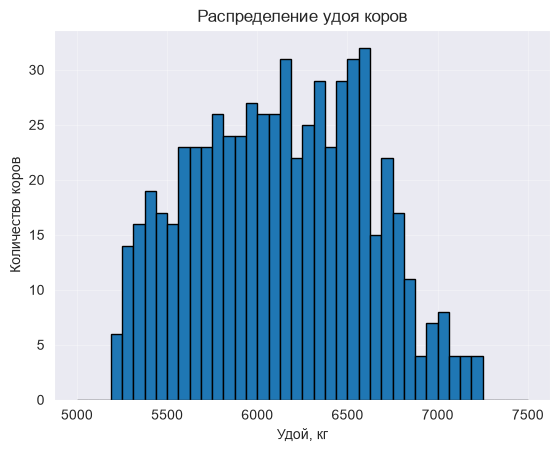

In [972]:
farm['удой, кг'].plot(kind = 'hist', bins = 40, edgecolor = 'black', range=(5000, 7500))
plt.title('Распределение удоя коров')
plt.ylabel('Количество коров')
plt.xlabel('Удой, кг')
plt.grid(alpha = 0.3)
plt.show()

farm = farm[farm['удой, кг'] != 45616].reset_index(drop=True)

#### Удалили выбросы для удоя. В сумме была удалена всего одна строка

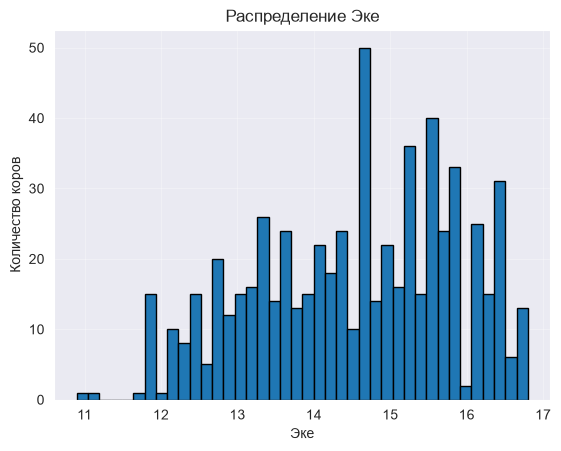

In [973]:
farm['эке'].plot(kind = 'hist', bins = 40, edgecolor = 'black')
plt.title('Распределение Эке')
plt.ylabel('Количество коров')
plt.xlabel('Эке')
plt.grid(alpha = 0.3)
plt.show()

#### Распределение ЭКЕ находится в диапазоне от 11 до 17

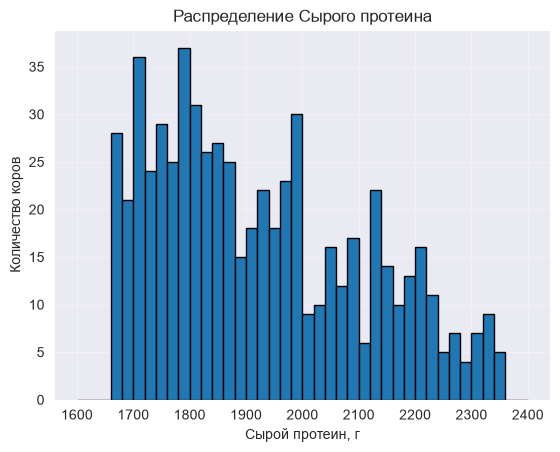

In [974]:
farm['сырой протеин, г'].plot(kind = 'hist', bins = 40, edgecolor = 'black', range=(1600, 2400))
plt.title('Распределение Сырого протеина')
plt.ylabel('Количество коров')
plt.xlabel('Сырой протеин, г')
plt.grid(alpha = 0.3)
plt.show()

#### Сырой протеин находится в диапазоне от 1600 до 2400. Пик приходится на 1700 и 2000 г

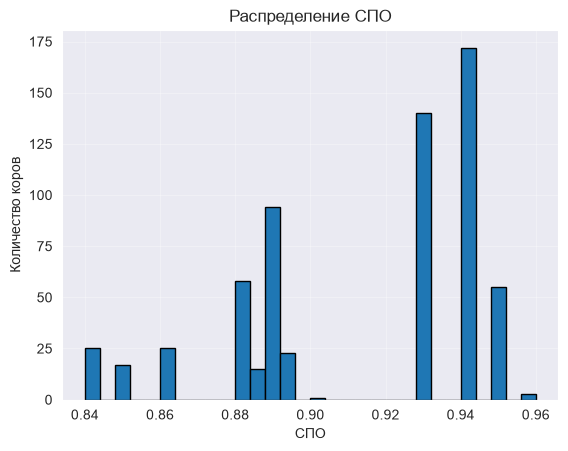

In [975]:
farm['спо'].plot(kind = 'hist', bins = 30, edgecolor = 'black')
plt.title('Распределение СПО')
plt.ylabel('Количество коров')
plt.xlabel('СПО')
plt.grid(alpha = 0.3)
plt.show()

#### На гистограмме видно, что СПО может быть преобразовано в категориальный бинарный признак

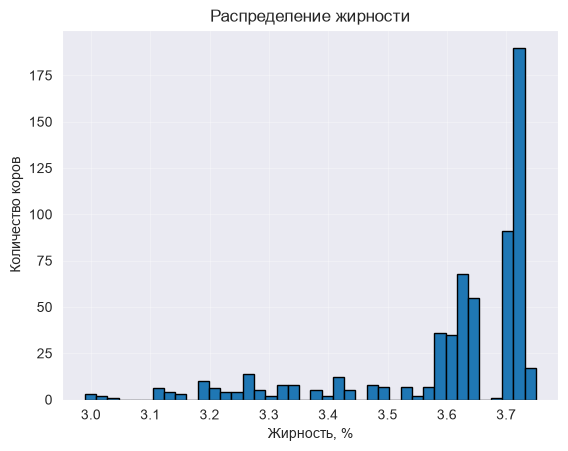

In [976]:
farm['жирность,%'].plot(kind = 'hist', bins = 40, edgecolor = 'black')
plt.title('Распределение жирности')
plt.ylabel('Количество коров')
plt.xlabel('Жирность, %')
plt.grid(alpha = 0.3)
plt.show()

#### На гистограмме видно, что жирность также можно преобразовать в категориальный бинарный признак

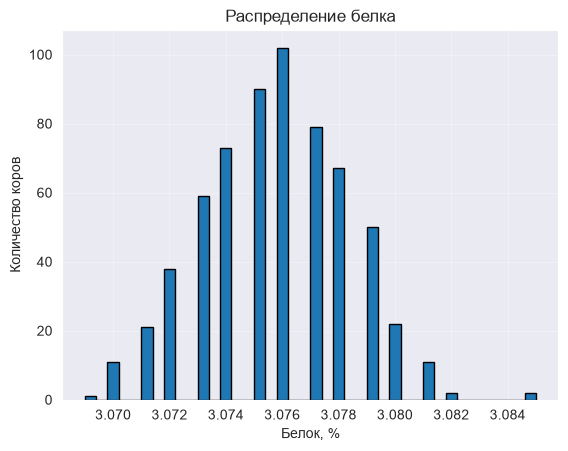

In [977]:
farm['белок,%'].plot(kind = 'hist', bins = 40, edgecolor = 'black')
plt.title('Распределение белка')
plt.ylabel('Количество коров')
plt.xlabel('Белок, %')
plt.grid(alpha = 0.3)
plt.show()

#### Распределение белка

### Вывод
##### В удое был обнаружен выброс, который был удален. В остальных столбцах выбросов не было. СПО и жирность можно преобразовать в категориальные бинарные признаки

## Шаг 4. Корреляционный анализ

In [978]:
categorical_columns = ['тип пастбища', 'порода', 'порода папы быка', 'вкус молока', 'возраст']
quantitative_columns = ['удой, кг', 'эке', 'сырой протеин, г', 'спо', 'жирность,%', 'белок,%']

In [979]:
corr_matrix = farm[quantitative_columns].corr()
corr_matrix

,"удой, кг",эке,"сырой протеин, г",спо,"жирность,%","белок,%"
"удой, кг",1.000000,0.765098,0.446731,0.806339,0.600902,0.002966
эке,0.765098,1.000000,0.387875,0.749007,0.637279,-0.008939
"сырой протеин, г",0.446731,0.387875,1.000000,0.446332,0.357793,0.226802
спо,0.806339,0.749007,0.446332,1.000000,0.629098,0.073718
"жирность,%",0.600902,0.637279,0.357793,0.629098,1.000000,-0.026542
"белок,%",0.002966,-0.008939,0.226802,0.073718,-0.026542,1.000000


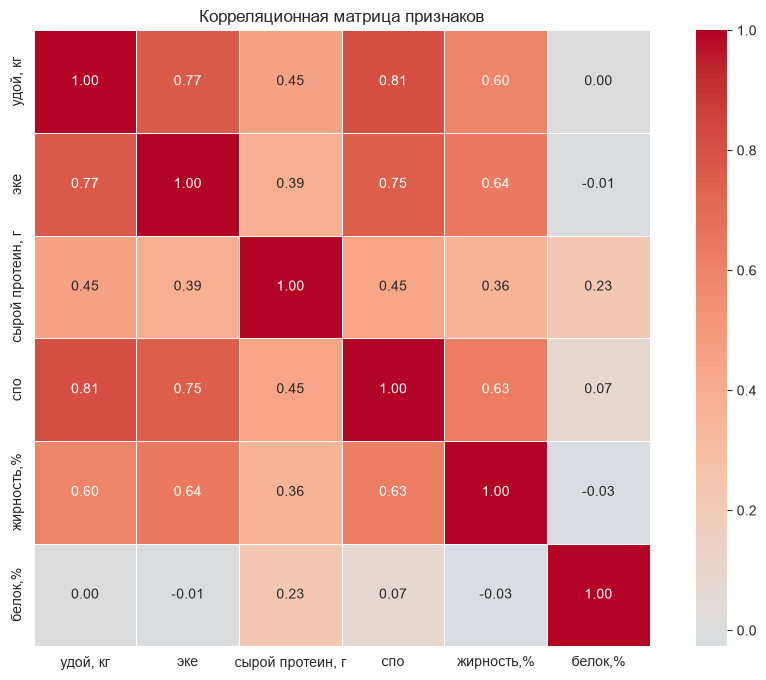

In [980]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', linewidths=0.5, cmap='coolwarm', square=True, center=0)
plt.title('Корреляционная матрица признаков')
plt.show()

#### По коэффициентам корреляции наиболее сильная положительная линейная связь наблюдается между удоем и СПО, а также между удоем и ЭКЕ. Умеренная связь выявлена с жирностью и сырым протеином, тогда как связь с содержанием белка практически отсутствует. Диаграммы рассеяния позволяют дополнительно оценить характер зависимостей и различия между породами.

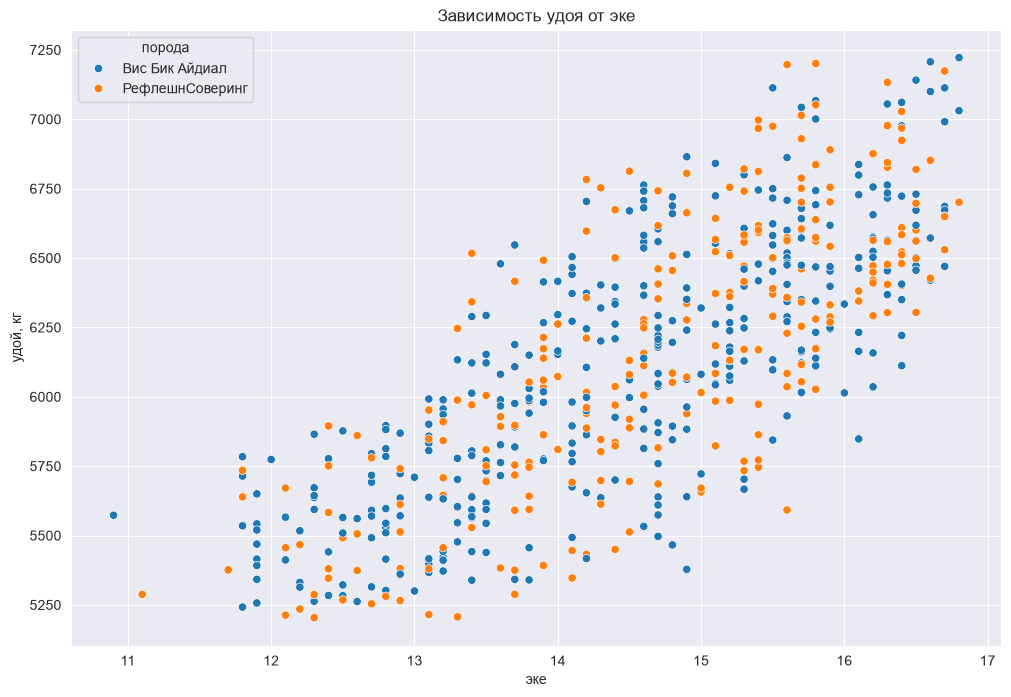

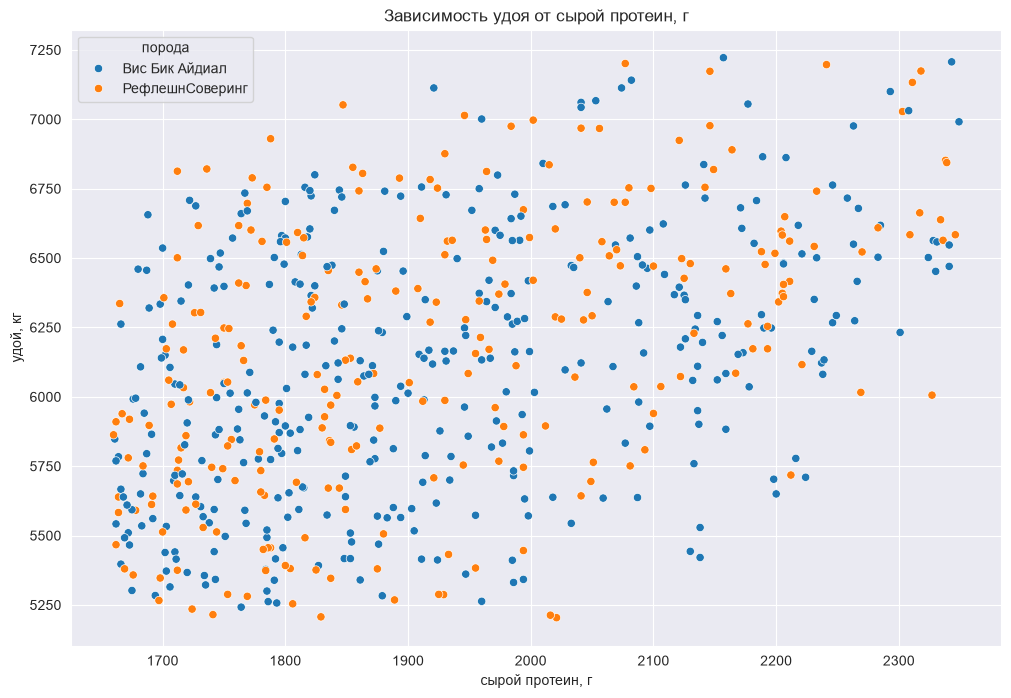

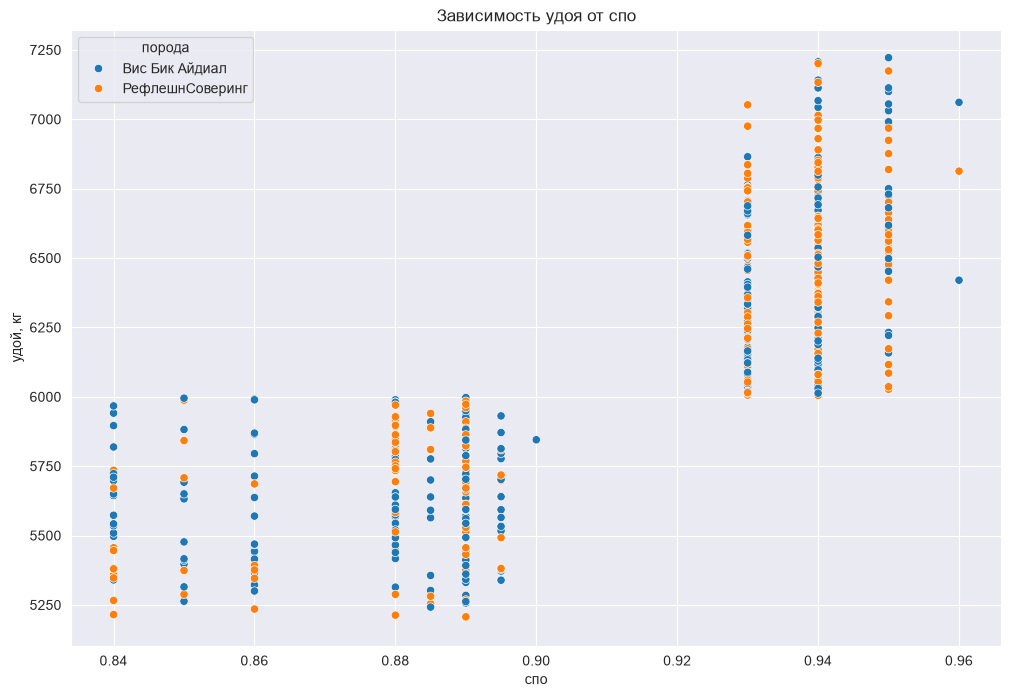

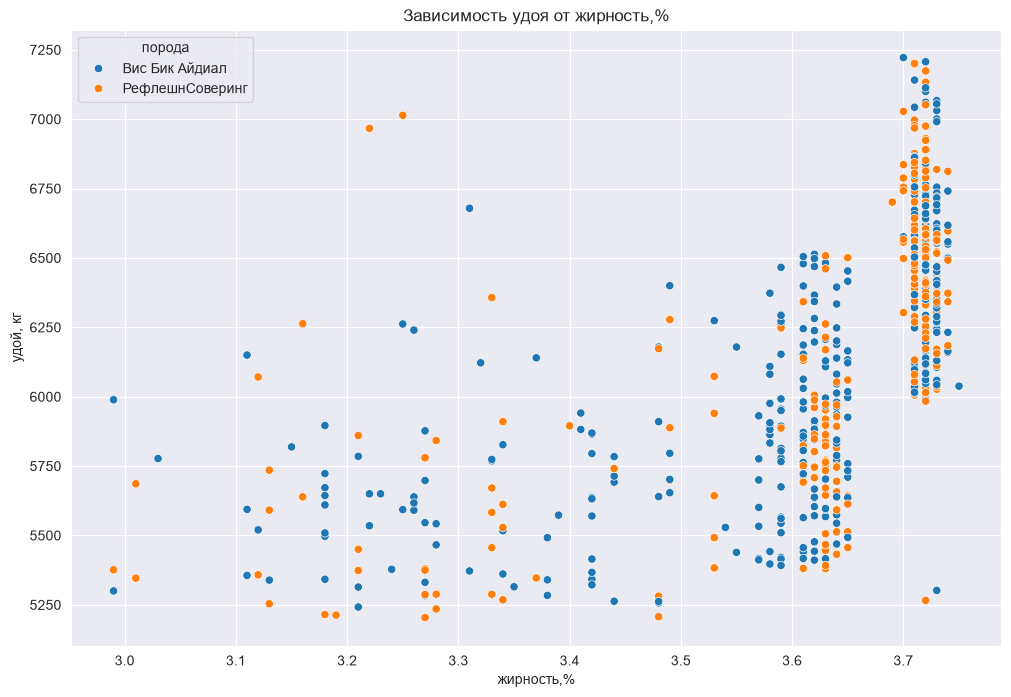

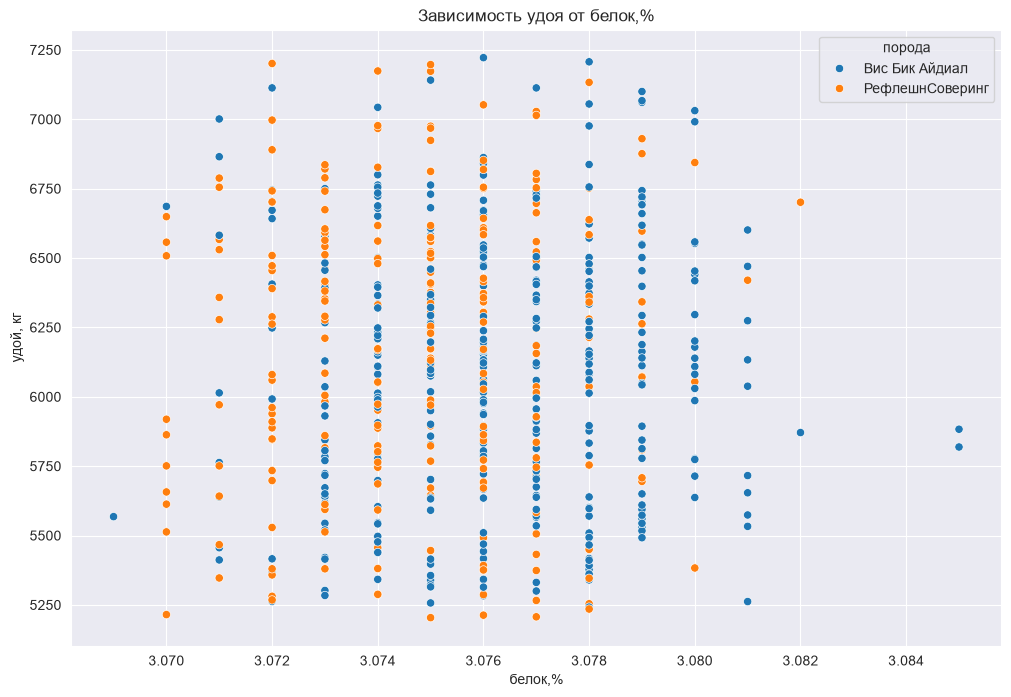

In [981]:
for column in quantitative_columns:
    if column != 'удой, кг':
        plt.figure(figsize=(12, 8))
        sns.scatterplot(data=farm,x=column,y='удой, кг',hue='порода')
        plt.title(f'Зависимость удоя от {column}')
        plt.show()

#### Корреляционный анализ показал сильную положительную связь удоя с СПО (0.81) и ЭКЕ (0.77), умеренную — с жирностью (0.60) и сырым протеином (0.45). Связь с белком отсутствует (0.00), а высокая корреляция между ЭКЕ и СПО (0.75) может указывать на мультиколлинеарность.

## Шаг 5. Задача регрессии

In [982]:
quantitative_features = ['эке','сырой протеин, г','спо','жирность,%','белок,%']
categorical_features = ['порода','тип пастбища','порода папы быка','возраст']
features = quantitative_features + categorical_features

In [983]:
X = farm[features]
Y = farm['удой, кг']
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

encoder = OneHotEncoder(drop='first' ,handle_unknown='ignore', sparse_output=False)
encoder.fit(X_train[categorical_features])
X_train_encoded = encoder.transform(X_train[categorical_features])
X_test_encoded = encoder.transform(X_test[categorical_features])

print(X_train_encoded.shape)
print(X_test_encoded.shape)

(502, 4)
(126, 4)


In [984]:
scaler = StandardScaler()

In [985]:
scaler.fit(X_train[quantitative_features])
X_train_scaled = scaler.transform(X_train[quantitative_features])
X_test_scaled = scaler.transform(X_test[quantitative_features])

X_train_ready = np.hstack([X_train_scaled, X_train_encoded])
X_test_ready = np.hstack([X_test_scaled, X_test_encoded])

print(X_train_ready.shape)
print(X_test_ready.shape)

(502, 9)
(126, 9)


#### Обучение модели линейной регрессии 1

In [986]:
lr_model_1 = LinearRegression()
lr_model_1.fit(X_train_ready, y_train)
predictions_lr = lr_model_1.predict(X_test_ready)
r2_model_1 = r2_score(y_test, predictions_lr)
print('R² первой модели:', r2_model_1)

R² первой модели: 0.8012891555263226


#### Первая модель показала R² = 0.80. Это значит, что она достаточно хорошо объясняет различия в удое коров — примерно на 80%. Однако для полной оценки нужно дополнительно проверить величину ошибок модели.

In [987]:
residuals_model_1 = y_test - predictions_lr
residuals_model_1.head(5)

581    -68.376398
591     57.299605
550    -85.427831
213    -80.276051
485   -302.337447
Name: удой, кг, dtype: float64

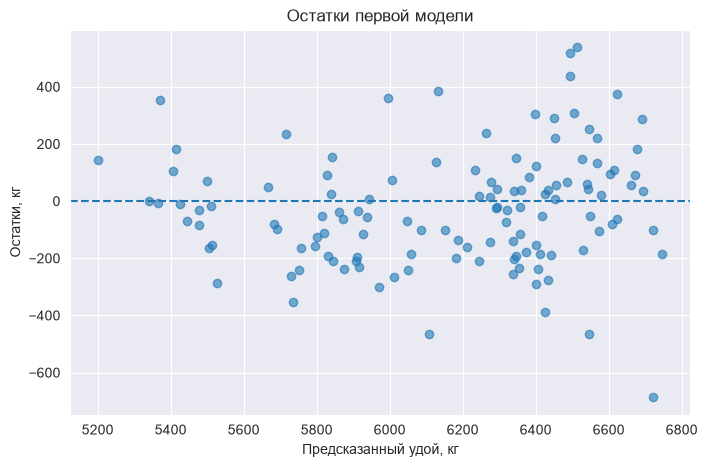

In [988]:
plt.figure(figsize=(8, 5))
plt.scatter(predictions_lr, residuals_model_1, alpha=0.6)
plt.axhline(y=0, linestyle='--')
plt.xlabel('Предсказанный удой, кг')
plt.ylabel('Остатки, кг')
plt.title('Остатки первой модели')
plt.show()

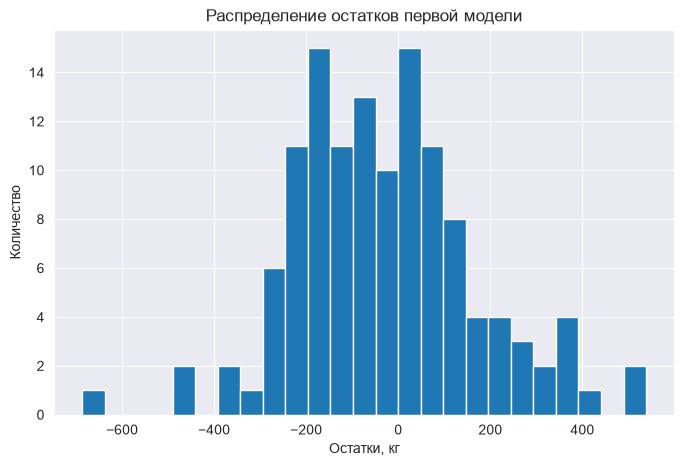

In [989]:
plt.figure(figsize=(8, 5))
plt.hist(residuals_model_1, bins=25)
plt.xlabel('Остатки, кг')
plt.ylabel('Количество')
plt.title('Распределение остатков первой модели')
plt.show()

#### Остатки в основном расположены вокруг нуля, однако заметна некоторая структура и присутствуют отдельные большие ошибки. Это означает, что первая модель достаточно хорошо описывает данные, но не полностью учитывает все зависимости. А сами остатки распределены менее равномерно

### Обучение модели линейной регрессии 2

#### Зависимость удоя от СПО имеет нелинейный характер, поэтому преобразуем СПО в бинарный категориальный признак. Также добавим квадрат ЭКЕ для учёта нелинейной зависимости.

In [990]:
farm_2 = farm.copy()
farm_2['эке квадрат'] = farm_2['эке'] ** 2
cut_off_spo = 0.9
farm_2['спо_группа'] = farm_2['спо'].apply(
    lambda x: 1 if x > cut_off_spo else 0)
farm_2['спо_группа'].value_counts()
farm_2[['спо', 'спо_группа', 'эке', 'эке квадрат']].head()

,спо,спо_группа,эке,эке квадрат
0,0.890,0,14.2,201.64
1,0.890,0,12.8,163.84
2,0.885,0,14.0,196.00
3,0.885,0,12.4,153.76
4,0.885,0,12.8,163.84


#### Создадим новую модель с учётом новых признаков

In [991]:
quantitative_features_2 = ['эке','эке квадрат','сырой протеин, г','жирность,%','белок,%']
categorical_features_2 = ['спо_группа','порода','тип пастбища','порода папы быка','возраст']
features_2 = quantitative_features_2 + categorical_features_2

In [992]:
X_2 = farm_2[features_2]
y_2 = farm_2['удой, кг']
X_2_train, X_2_test, y_2_train, y_2_test = train_test_split(X_2,y_2,test_size=0.2,random_state=42)

encoder_2 = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
encoder_2.fit(X_2_train[categorical_features_2])
X_2_train_encoded = encoder_2.transform(X_2_train[categorical_features_2])
X_2_test_encoded = encoder_2.transform(X_2_test[categorical_features_2])

In [993]:
scaler_2 = StandardScaler()

In [994]:
scaler_2.fit(X_2_train[quantitative_features_2])
X_2_train_scaled = scaler_2.transform(X_2_train[quantitative_features_2])
X_2_test_scaled = scaler_2.transform(X_2_test[quantitative_features_2])

X_2_train_ready = np.hstack([X_2_train_scaled,X_2_train_encoded])
X_2_test_ready = np.hstack([X_2_test_scaled,X_2_test_encoded])

print(X_2_train_ready.shape)
print(X_2_test_ready.shape)

(502, 10)
(126, 10)


#### Обучение модели линейной регрессии 2

In [995]:
lr_model_2 = LinearRegression()
lr_model_2.fit(X_2_train_ready, y_2_train)
predictions_lr_2 = lr_model_2.predict(X_2_test_ready)
r2_model_2 = r2_score(y_2_test, predictions_lr_2)

print('R² первой модели:', r2_model_1)
print('R² второй модели:', r2_model_2)

R² первой модели: 0.8012891555263226
R² второй модели: 0.8185961995521684


#### Вторая модель показала более высокий результат: R² увеличился с 0.80 до 0.82. Значит, преобразование СПО в бинарный признак и добавление квадрата ЭКЕ немного улучшили качество прогнозирования.

In [996]:
residuals_model_2 = y_2_test - predictions_lr_2
residuals_model_2.head(5)

581     28.178096
591    -28.273613
550    -76.343135
213    -57.347103
485   -181.346160
Name: удой, кг, dtype: float64

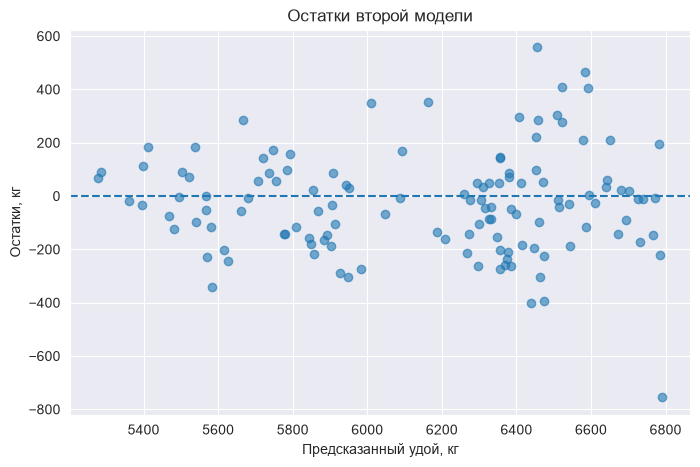

In [997]:
plt.figure(figsize=(8, 5))
plt.scatter(predictions_lr_2, residuals_model_2, alpha=0.6)
plt.axhline(y=0, linestyle='--')
plt.xlabel('Предсказанный удой, кг')
plt.ylabel('Остатки, кг')
plt.title('Остатки второй модели')
plt.show()

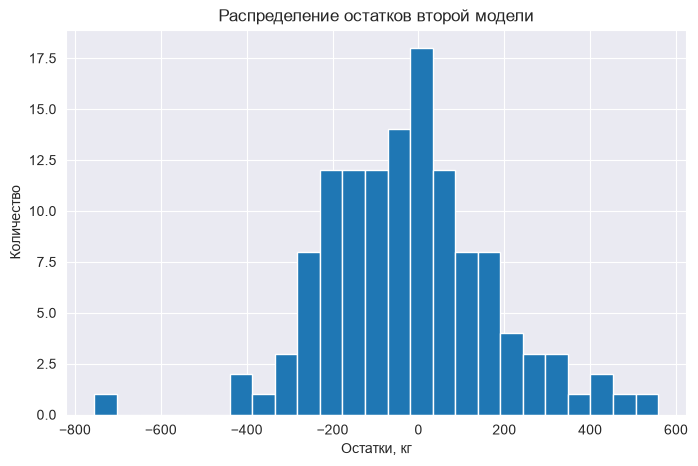

In [998]:
plt.figure(figsize=(8, 5))
plt.hist(residuals_model_2, bins=25)
plt.xlabel('Остатки, кг')
plt.ylabel('Количество')
plt.title('Распределение остатков второй модели')
plt.show()

#### Большинство ошибок второй модели находится около нуля, однако присутствуют отдельные крупные отклонения. В целом распределение остатков приемлемое, но модель всё ещё допускает заметные ошибки для некоторых коров.

### Обучение модели линейной регрессии 3

In [999]:
farm_3 = farm_2.merge(dad[['id', 'имя папы']],how='inner',on='id')

#### Создадим новую модель с учётом нового признака 'имя папы'

In [1000]:
quantitative_features_3 = ['эке','эке квадрат','сырой протеин, г','жирность,%','белок,%']
categorical_features_3 = ['спо_группа','порода','тип пастбища','порода папы быка','возраст', 'имя папы']
features_3 = quantitative_features_3 + categorical_features_3

In [1001]:
X_3 = farm_3[features_3]
y_3 = farm_3['удой, кг']
X_3_train, X_3_test, y_3_train, y_3_test = train_test_split(X_3, y_3, test_size=0.2, random_state=42)

encoder_3 = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
encoder_3.fit(X_3_train[categorical_features_3])
X_3_train_encoded = encoder_3.transform(X_3_train[categorical_features_3])
X_3_test_encoded = encoder_3.transform(X_3_test[categorical_features_3])

In [1002]:
scaler_3 = StandardScaler()

In [1003]:
scaler_3.fit(X_3_train[quantitative_features_3])
X_3_train_scaled = scaler_3.transform(X_3_train[quantitative_features_3])
X_3_test_scaled = scaler_3.transform(X_3_test[quantitative_features_3])

X_3_train_ready = np.hstack([X_3_train_scaled, X_3_train_encoded])
X_3_test_ready = np.hstack([X_3_test_scaled, X_3_test_encoded])

print(X_3_train_ready.shape)
print(X_3_test_ready.shape)

(502, 13)
(126, 13)


#### Обучение модели линейной регрессии 3

In [1004]:
lr_model_3 = LinearRegression()
lr_model_3.fit(X_3_train_ready, y_3_train)
predictions_lr_3 = lr_model_3.predict(X_3_test_ready)
r2_model_3 = r2_score(y_3_test, predictions_lr_3)

print('R² первой модели:', r2_model_1)
print('R² второй модели:', r2_model_2)
print('R² третей модели:', r2_model_3)

R² первой модели: 0.8012891555263226
R² второй модели: 0.8185961995521684
R² третей модели: 0.8342469210836765


In [1005]:
residuals_model_3 = y_3_test - predictions_lr_3
residuals_model_3.head(5)

581    -25.040400
591    -46.143538
550   -113.255993
213    -28.032527
485   -183.802327
Name: удой, кг, dtype: float64

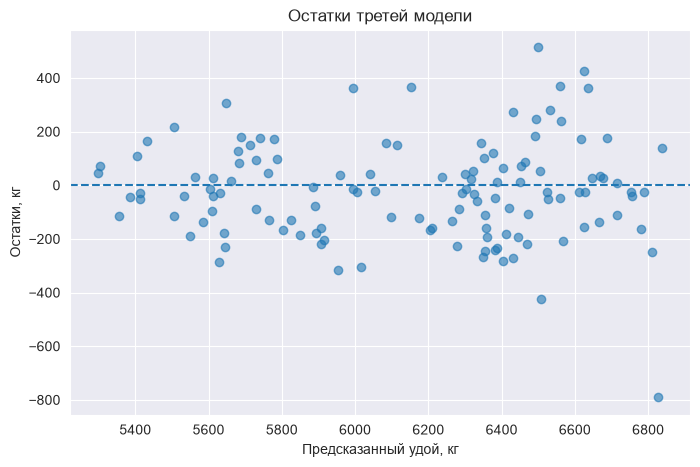

In [1006]:
plt.figure(figsize=(8, 5))
plt.scatter(predictions_lr_3, residuals_model_3, alpha=0.6)
plt.axhline(y=0, linestyle='--')
plt.xlabel('Предсказанный удой, кг')
plt.ylabel('Остатки, кг')
plt.title('Остатки третей модели')
plt.show()

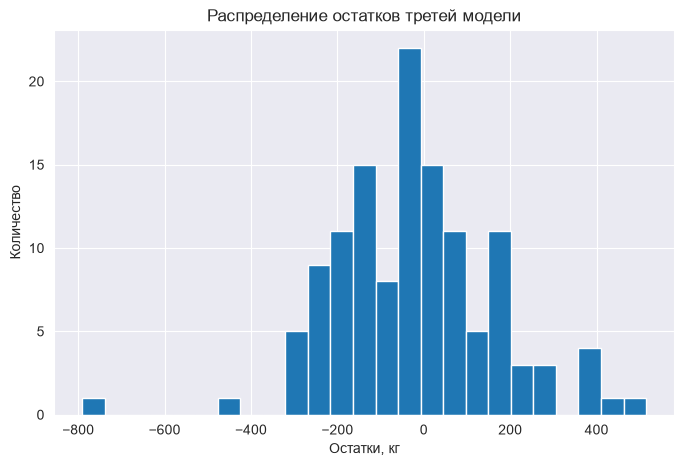

In [1007]:
plt.figure(figsize=(8, 5))
plt.hist(residuals_model_3, bins=25)
plt.xlabel('Остатки, кг')
plt.ylabel('Количество')
plt.title('Распределение остатков третей модели')
plt.show()

### Вывод

Были обучены три модели линейной регрессии. Значение R² последовательно увеличивалось: с 0.801 у первой модели до 0.819 у второй и 0.834 у третьей.

Лучший результат показала третья модель с дополнительным признаком «имя папы». Остатки в основном сосредоточены около нуля, хотя сохраняются отдельные крупные ошибки. Поэтому для дальнейшего прогнозирования следует выбрать третью модель.

### Сравнение моделей и выбор лучшей

#### По показателю R² лучшей моделью является модель 3
#### Также посчитаем метрики MSE, MAE и RMSE

In [1008]:
model_1_mse = mean_squared_error(y_test, predictions_lr)
model_1_mae = mean_absolute_error(y_test, predictions_lr)
model_1_rmse = root_mean_squared_error(y_test, predictions_lr)

model_2_mse = mean_squared_error(y_2_test, predictions_lr_2)
model_2_mae = mean_absolute_error(y_2_test, predictions_lr_2)
model_2_rmse = root_mean_squared_error(y_2_test, predictions_lr_2)

model_3_mse = mean_squared_error(y_3_test, predictions_lr_3)
model_3_mae = mean_absolute_error(y_3_test, predictions_lr_3)
model_3_rmse = root_mean_squared_error(y_3_test, predictions_lr_3)

print('Модель 1:')
print('MSE:', model_1_mse)
print('MAE:', model_1_mae)
print('RMSE:', model_1_rmse)
print()

print('Модель 2:')
print('MSE:', model_2_mse)
print('MAE:', model_2_mae)
print('RMSE:', model_2_rmse)
print()

print('Модель 3:')
print('MSE:', model_3_mse)
print('MAE:', model_3_mae)
print('RMSE:', model_3_rmse)

Модель 1:
MSE: 41251.4553728962
MAE: 158.86949147836586
RMSE: 203.10454296469146

Модель 2:
MSE: 37658.59280839986
MAE: 148.4057862831739
RMSE: 194.058220151582

Модель 3:
MSE: 34409.575159057866
MAE: 141.52805807783855
RMSE: 185.49818101280096


#### Третья модель показала лучшие результаты по всем метрикам. Выберем её для прогноза удоя коров

In [1009]:
train_predictions_3  =lr_model_3.predict(X_3_train_ready)
train_errors_3 = y_3_train - train_predictions_3
lower_quantile_3 = np.quantile(train_errors_3, 0.025)
upper_quantile_3 = np.quantile(train_errors_3, 0.975)

print(f'2.5-й процентиль ошибки: {lower_quantile_3}')
print(f'97.5-й процентиль ошибки: {upper_quantile_3}')

test_predictions_3 =lr_model_3.predict(X_3_test_ready)
pred_lower = test_predictions_3 + lower_quantile_3
pred_upper = test_predictions_3 + upper_quantile_3

print(f'Предсказанное значение: {test_predictions_3[0]}')
print(f'Доверительный интервал: [{pred_lower[0]}, {pred_upper[0]}]')

2.5-й процентиль ошибки: -315.34692312120535
97.5-й процентиль ошибки: 368.2606034670623
Предсказанное значение: 6005.040399516552
Доверительный интервал: [5689.693476395346, 6373.301002983614]


#### Прогноз удоя коров, которых фермер хочет купить

In [1010]:
mean_eke = farm_3['эке'].mean() * 1.05
mean_protein = farm_3['сырой протеин, г'].mean() * 1.05
mean_spo = farm_3['спо'].mean() * 1.05

cow_buy_regression = buy.copy()
cow_buy_regression['тип пастбища'] = cow_buy_regression['тип пастбища'].str.capitalize()
cow_buy_regression = cow_buy_regression.rename({'текущая_жирность,%': 'жирность,%','текущий_уровень_белок,%': 'белок,%',}, axis=1)
cow_buy_regression['эке'] = mean_eke
cow_buy_regression['эке квадрат'] = cow_buy_regression['эке'] ** 2
cow_buy_regression['сырой протеин, г'] = mean_protein
cow_buy_regression['спо'] = mean_spo
cow_buy_regression['спо_группа'] = cow_buy_regression['спо'].apply(lambda x: 1 if x > 0.9 else 0) #превращаем в бинарную группу 0 ил 1

cow_buy_regression[features_3].head()

,эке,эке квадрат,"сырой протеин, г","жирность,%","белок,%",спо_группа,порода,тип пастбища,порода папы быка,возраст,имя папы
0,15.276162,233.361138,2019.947532,3.58,3.076,1,Вис Бик Айдиал,Холмистое,Айдиал,более_2_лет,Геркулес
1,15.276162,233.361138,2019.947532,3.54,3.081,1,Вис Бик Айдиал,Равнинное,Соверин,менее_2_лет,Буйный
2,15.276162,233.361138,2019.947532,3.59,3.074,1,РефлешнСоверинг,Равнинное,Соверин,более_2_лет,Барин
3,15.276162,233.361138,2019.947532,3.40,3.061,1,РефлешнСоверинг,Холмистое,Айдиал,более_2_лет,Буйный
4,15.276162,233.361138,2019.947532,3.64,3.074,1,РефлешнСоверинг,Равнинное,Айдиал,более_2_лет,Буйный


#### Подготовим данные

In [1011]:
cow_buy_encoded = encoder_3.transform(cow_buy_regression[categorical_features_3])
cow_buy_scaled = scaler_3.transform(cow_buy_regression[quantitative_features_3])
cow_buy_ready = np.hstack([cow_buy_scaled, cow_buy_encoded])

#### Добавим прогноз и границу интервала

In [1012]:
cow_buy_predicted  = lr_model_3.predict(cow_buy_ready)
cow_buy_regression['прогноз удоя'] = cow_buy_predicted
cow_buy_regression['нижняя граница'] = (cow_buy_predicted + lower_quantile_3)
cow_buy_regression['верхняя граница'] = (cow_buy_predicted + upper_quantile_3)
cow_buy_regression[['прогноз удоя', 'нижняя граница', 'верхняя граница']].head()

,прогноз удоя,нижняя граница,верхняя граница
0,6556.655390,6241.308467,6924.915994
1,6193.153062,5877.806138,6561.413665
2,6232.732886,5917.385963,6600.993489
3,6652.200358,6336.853434,7020.460961
4,6512.556273,6197.209350,6880.816877


### Вывод

Для прогнозирования удоя была выбрана третья модель, так как она показала лучшее качество среди трёх моделей.
Для коров из `cow_buy.csv` были рассчитаны прогнозные значения удоя и 95%-е интервалы прогноза. Среди рассмотренных коров есть животные с прогнозируемым удоем выше 6000 кг, однако при выборе следует учитывать и нижнюю границу интервала, так как она отражает возможную ошибку модели.

## Шаг 6. Задача классификации

In [1013]:
farm['вкус молока'].unique()
farm['вкус молока'].value_counts()
farm['вкус молока'].value_counts(normalize = True)

вкус молока
вкусно       0.589172
не вкусно    0.410828
Name: proportion, dtype: float64

In [1014]:
farm_class = farm.merge(dad[['id', 'имя папы']],how='inner',on='id')
categorical_features_class = ['порода', 'тип пастбища', 'порода папы быка', 'имя папы', 'возраст']
quantitative_features_class = ['эке','сырой протеин, г','спо','жирность,%','белок,%']
features_class = categorical_features_class + quantitative_features_class
X = farm_class[features_class]
y = farm_class['вкус молока']

In [1015]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

вкус молока
вкусно       0.587302
не вкусно    0.412698
Name: proportion, dtype: float64

#### Кодируем категориальные признаки

In [1016]:
encoder_class = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
encoder_class.fit(X_train[categorical_features_class])
X_train_encoded = encoder_class.transform(X_train[categorical_features_class])
X_test_encoded = encoder_class.transform(X_test[categorical_features_class])

In [1017]:
scaler_class = StandardScaler()
scaler_class.fit(X_train[quantitative_features_class])
X_train_scaled_class = scaler_class.transform(X_train[quantitative_features_class])
X_test_scaled_class = scaler_class.transform(X_test[quantitative_features_class])

X_train_ready_class = np.hstack([X_train_scaled_class,X_train_encoded])
X_test_ready_class = np.hstack([X_test_scaled_class,X_test_encoded])

print(X_train_ready_class.shape)
print(X_test_ready_class.shape)

(502, 12)
(126, 12)


In [1018]:
model_class = LogisticRegression(random_state=42, max_iter=1000)
model_class.fit(X_train_ready_class, y_train)
y_pred_class = model_class.predict(X_test_ready_class)

In [1019]:
accuracy = accuracy_score(y_test, y_pred_class)
recall = recall_score(y_test, y_pred_class, pos_label='вкусно')
precision = precision_score(y_test, y_pred_class, pos_label='вкусно') #считаем класс 'вкусно' главным классом

print('Accuracy:', accuracy)
print('Recall:', recall)
print('Precision:', precision)

Accuracy: 0.6349206349206349
Recall: 0.7567567567567568
Precision: 0.6666666666666666


#### Делаем матрицу ошибок

In [1020]:
cm = confusion_matrix(y_test, y_pred_class, labels=['не вкусно', 'вкусно'])
print(cm)

[[24 28]
 [18 56]]


In [1021]:
print(recall_score(y_test, y_pred_class, pos_label='вкусно'))
print(precision_score(y_test, y_pred_class, pos_label='вкусно'))

0.7567567567567568
0.6666666666666666


#### Создаем матрицу ошибок

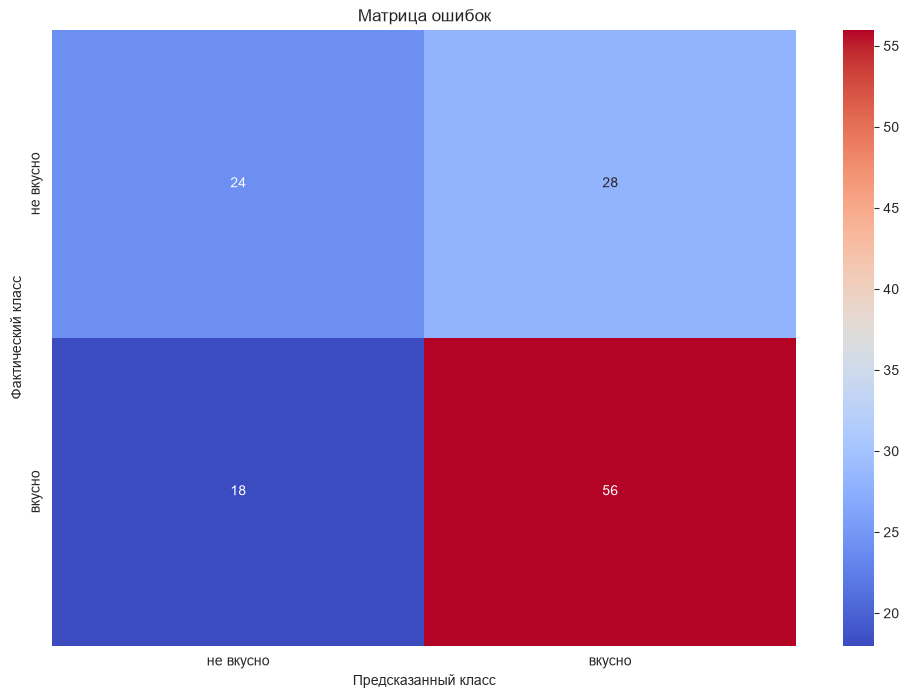

In [1022]:
conf_matrix = confusion_matrix(y_test,y_pred_class,labels=['не вкусно', 'вкусно'])

plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='coolwarm',xticklabels=['не вкусно', 'вкусно'],yticklabels=['не вкусно', 'вкусно'])
plt.title('Матрица ошибок')
plt.xlabel('Предсказанный класс')
plt.ylabel('Фактический класс')
plt.show()

### Вывод

Модель правильно классифицирует **56 коров с вкусным молоком** и **24 коровы с невкусным молоком**. При этом **28 коров с невкусным молоком** были ошибочно классифицированы как коровы с вкусным молоком.
Для заказчика эта ошибка является наиболее критичной, поскольку она может привести к покупке неподходящей коровы. Поэтому в данной задаче более важной метрикой является **Precision**, который составляет **0.67**.
Значение **Recall составляет 0.76**, то есть модель правильно определяет около 76% коров, которые действительно дают вкусное молоко.

#### Уменьшим количество False Positive, увеличив порог принадлежности к классу 1 (вкусное молоко)

In [1023]:
taste_index = list(model_class.classes_).index('вкусно')
y_proba_class = model_class.predict_proba(X_test_ready_class)[:, taste_index]

In [1024]:
for threshold in [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9]:
    y_pred_threshold = np.where(y_proba_class >= threshold,'вкусно','не вкусно')
    precision = precision_score(y_test,y_pred_threshold,pos_label='вкусно',zero_division=0)
    recall = recall_score(y_test,y_pred_threshold,pos_label='вкусно')
    cm = confusion_matrix(y_test,y_pred_threshold,labels=['не вкусно', 'вкусно'])

    print('Порог:', threshold)
    print('Precision:', round(precision, 3))
    print('Recall:', round(recall, 3))
    print('Критичных ошибок:', cm[0, 1])
    print()

Порог: 0.5
Precision: 0.667
Recall: 0.757
Критичных ошибок: 28

Порог: 0.6
Precision: 0.672
Recall: 0.554
Критичных ошибок: 20

Порог: 0.7
Precision: 0.774
Recall: 0.324
Критичных ошибок: 7

Порог: 0.75
Precision: 0.75
Recall: 0.203
Критичных ошибок: 5

Порог: 0.8
Precision: 1.0
Recall: 0.081
Критичных ошибок: 0

Порог: 0.85
Precision: 0.0
Recall: 0.0
Критичных ошибок: 0

Порог: 0.9
Precision: 0.0
Recall: 0.0
Критичных ошибок: 0



In [1025]:
threshold = 0.8
y_pred_threshold = np.where(y_proba_class >= threshold,'вкусно','не вкусно')
precision_threshold = precision_score(y_test,y_pred_threshold,pos_label='вкусно')
recall_threshold = recall_score(y_test,y_pred_threshold,pos_label='вкусно')

print('Precision:', precision_threshold)
print('Recall:', recall_threshold)

Precision: 1.0
Recall: 0.08108108108108109


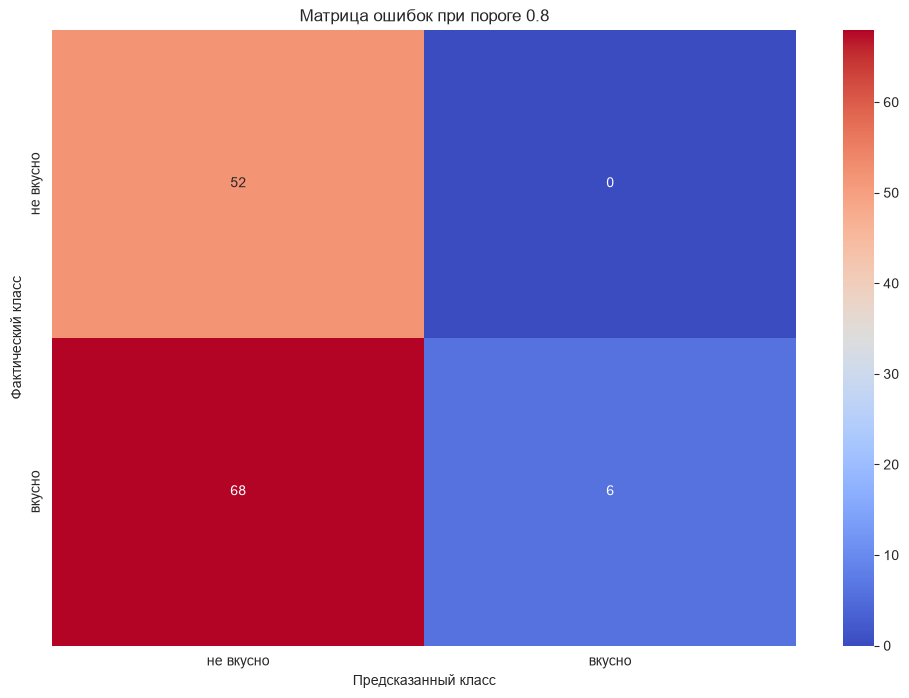

In [1026]:
conf_matrix_2 = confusion_matrix(y_test,y_pred_threshold,labels=['не вкусно', 'вкусно'])

plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix_2,annot=True,fmt='d',cmap='coolwarm',xticklabels=['не вкусно', 'вкусно'],yticklabels=['не вкусно', 'вкусно'])
plt.title('Матрица ошибок при пороге 0.8')
plt.xlabel('Предсказанный класс')
plt.ylabel('Фактический класс')
plt.show()

#### Вывод после изменения порога

Для уменьшения критичной ошибки был увеличен порог классификации до **0.8**.
После изменения порога модель не допустила ни одной ошибки, при которой корова с невкусным молоком была бы ошибочно отнесена к классу «вкусно». Таким образом, количество критичных ошибок снизилось с **28 до 0**, а значение **Precision увеличилось с 0.67 до 1.0**.
При этом **Recall снизился с 0.76 до 0.08**, поскольку модель стала значительно строже относить коров к классу «вкусно». Из 74 коров с действительно вкусным молоком модель правильно определила только 6.
Таким образом, порог **0.8** позволяет полностью исключить критичную ошибку на тестовой выборке, но приводит к значительному снижению полноты модели. Модель становится более осторожной и рекомендует только тех коров, в качестве которых она наиболее уверена.

#### Прогноз вкуса молока коров, которых фермер хочет купить

In [1027]:
print(buy.columns.tolist())
buy.head()

['порода', 'тип пастбища', 'порода папы быка', 'имя папы', 'текущая_жирность,%', 'текущий_уровень_белок,%', 'возраст']


,порода,тип пастбища,порода папы быка,имя папы,"текущая_жирность,%","текущий_уровень_белок,%",возраст
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет


In [1028]:
buy_class = buy.rename(columns={'текущая_жирность,%': 'жирность,%','текущий_уровень_белок,%': 'белок,%'})
quantitative_features_class = ['жирность,%','белок,%']
categorical_features_class = ['порода','тип пастбища','порода папы быка','имя папы','возраст']
features_class = categorical_features_class + quantitative_features_class

X = farm_class[features_class]
y = farm_class['вкус молока']

In [1029]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [1030]:
encoder_class = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
encoder_class.fit(X_train[categorical_features_class])
X_train_encoded = encoder_class.transform(X_train[categorical_features_class])
X_test_encoded = encoder_class.transform(X_test[categorical_features_class])

In [1031]:
scaler_class = StandardScaler()
scaler_class.fit(X_train[quantitative_features_class])
X_train_scaled = scaler_class.transform(X_train[quantitative_features_class])
X_test_scaled = scaler_class.transform(X_test[quantitative_features_class])

In [1032]:
X_train_ready_class = np.hstack([X_train_scaled, X_train_encoded])
X_test_ready_class = np.hstack([X_test_scaled, X_test_encoded])

model_class = LogisticRegression(random_state=42, max_iter=1000)
model_class.fit(X_train_ready_class, y_train)
y_pred_class = model_class.predict(X_test_ready_class)

print('Accuracy:', accuracy_score(y_test, y_pred_class))
print('Recall:', recall_score(y_test, y_pred_class, pos_label='вкусно'))
print('Precision:', precision_score(y_test, y_pred_class, pos_label='вкусно'))

Accuracy: 0.6507936507936508
Recall: 0.8513513513513513
Precision: 0.65625


#### Строим матрицу ошибок

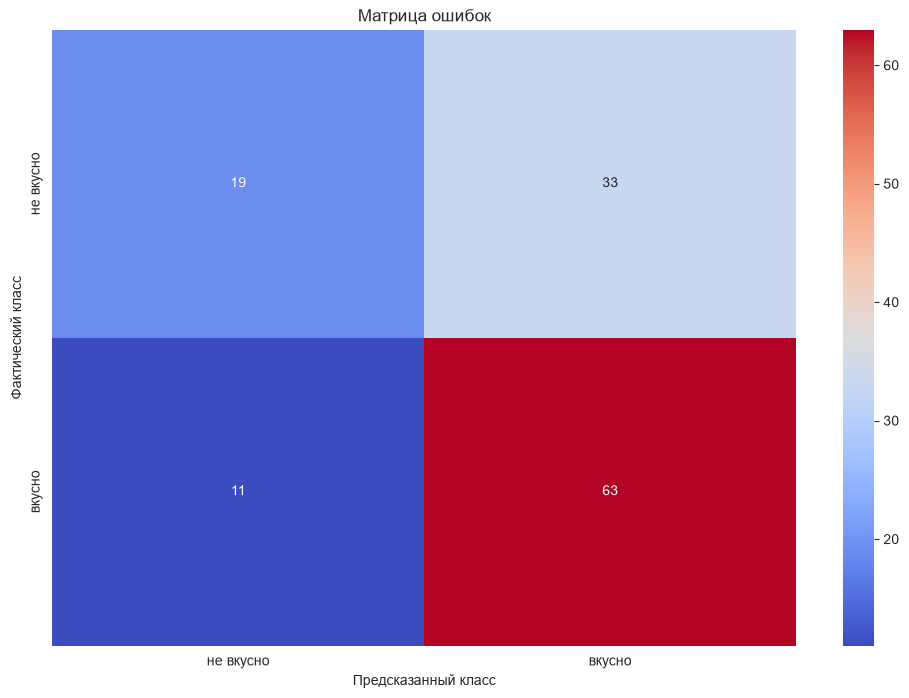

In [1033]:
conf_matrix = confusion_matrix(y_test, y_pred_class, labels=['не вкусно', 'вкусно'])
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='coolwarm', xticklabels=['не вкусно', 'вкусно'], yticklabels=['не вкусно', 'вкусно'])
plt.title('Матрица ошибок')
plt.xlabel('Предсказанный класс')
plt.ylabel('Фактический класс')
plt.show()

#### Получим вероятности класса 'вкусно'

In [1034]:
taste_index = list(model_class.classes_).index('вкусно')
y_proba_class = model_class.predict_proba(X_test_ready_class)[:, taste_index]

In [1035]:
for threshold in [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9]:
    y_pred_threshold = np.where(y_proba_class >= threshold, 'вкусно', 'не вкусно')
    precision = precision_score(y_test, y_pred_threshold, pos_label='вкусно', zero_division=0)
    recall = recall_score(y_test, y_pred_threshold, pos_label='вкусно')
    cm = confusion_matrix(y_test, y_pred_threshold, labels=['не вкусно', 'вкусно'])
    print('Порог:', threshold, '| Precision:', round(precision, 3), '| Recall:', round(recall, 3), '| Критичных ошибок:', cm[0, 1])

Порог: 0.5 | Precision: 0.656 | Recall: 0.851 | Критичных ошибок: 33
Порог: 0.6 | Precision: 0.677 | Recall: 0.568 | Критичных ошибок: 20
Порог: 0.7 | Precision: 0.731 | Recall: 0.257 | Критичных ошибок: 7
Порог: 0.75 | Precision: 0.6 | Recall: 0.081 | Критичных ошибок: 4
Порог: 0.8 | Precision: 1.0 | Recall: 0.014 | Критичных ошибок: 0
Порог: 0.85 | Precision: 0.0 | Recall: 0.0 | Критичных ошибок: 0
Порог: 0.9 | Precision: 0.0 | Recall: 0.0 | Критичных ошибок: 0


In [1036]:
threshold = 0.8
y_pred_threshold = np.where(y_proba_class >= threshold, 'вкусно', 'не вкусно')
print('Precision:', precision_score(y_test, y_pred_threshold, pos_label='вкусно'))
print('Recall:', recall_score(y_test, y_pred_threshold, pos_label='вкусно'))

Precision: 1.0
Recall: 0.013513513513513514


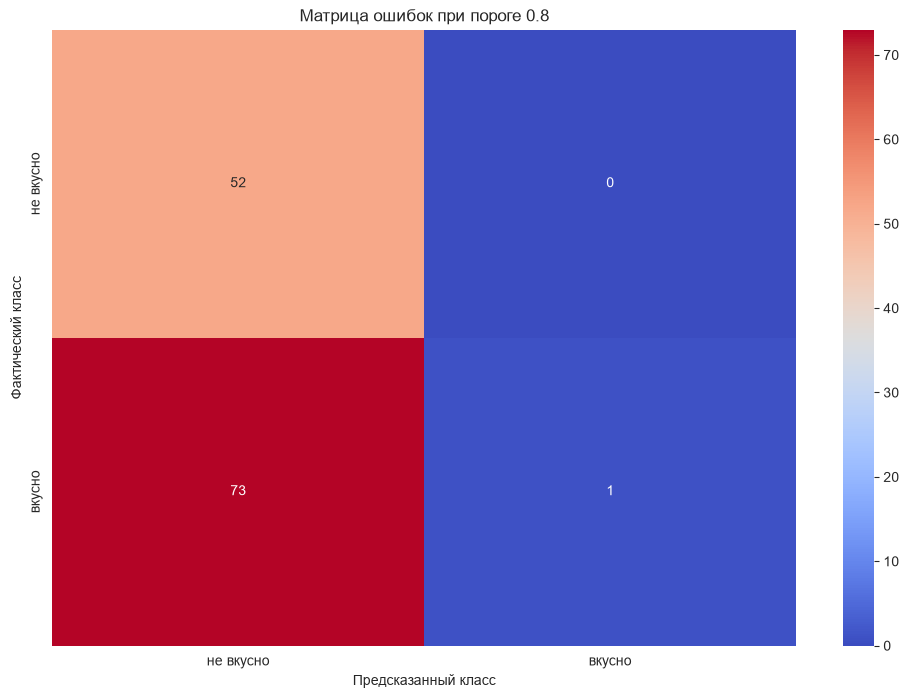

In [1037]:
conf_matrix_2 = confusion_matrix(y_test, y_pred_threshold, labels=['не вкусно', 'вкусно'])
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix_2, annot=True, fmt='d', cmap='coolwarm', xticklabels=['не вкусно', 'вкусно'], yticklabels=['не вкусно', 'вкусно'])
plt.title('Матрица ошибок при пороге 0.8')
plt.xlabel('Предсказанный класс')
plt.ylabel('Фактический класс')
plt.show()

#### Переходим к прогнозу

In [1038]:
buy_class['тип пастбища'] = buy_class['тип пастбища'].str.capitalize()

In [1039]:
buy_encoded = encoder_class.transform(buy_class[categorical_features_class])
buy_scaled = scaler_class.transform(buy_class[quantitative_features_class])
buy_ready_class = np.hstack([buy_scaled, buy_encoded])

In [1040]:
buy_proba_tasty = model_class.predict_proba(buy_ready_class)[:, taste_index]
buy_pred_taste = np.where(buy_proba_tasty >= 0.8, 'вкусно', 'не вкусно')

In [1041]:
buy_class['вероятность вкусного молока'] = buy_proba_tasty
buy_class['прогноз вкуса'] = buy_pred_taste
buy_class[['порода', 'имя папы', 'вероятность вкусного молока', 'прогноз вкуса']]

,порода,имя папы,вероятность вкусного молока,прогноз вкуса
0,Вис Бик Айдиал,Геркулес,0.696618,не вкусно
1,Вис Бик Айдиал,Буйный,0.563570,не вкусно
2,РефлешнСоверинг,Барин,0.520706,не вкусно
3,РефлешнСоверинг,Буйный,0.244257,не вкусно
4,РефлешнСоверинг,Буйный,0.481439,не вкусно
5,РефлешнСоверинг,Геркулес,0.076521,не вкусно
6,Вис Бик Айдиал,Буйный,0.608882,не вкусно
7,РефлешнСоверинг,Буйный,0.605723,не вкусно
8,Вис Бик Айдиал,Соловчик,0.157367,не вкусно
9,РефлешнСоверинг,Геркулес,0.531104,не вкусно


In [1044]:
print(buy_class['вероятность вкусного молока'].max())
buy_class.sort_values('вероятность вкусного молока', ascending=False).head()

0.7104075863097667


,порода,тип пастбища,порода папы быка,имя папы,"жирность,%","белок,%",возраст,вероятность вкусного молока,прогноз вкуса,прогноз удоя
13,Вис Бик Айдиал,Холмистое,Соверин,Соловчик,3.73,3.079,более_2_лет,0.710408,не вкусно,6312.352343
0,Вис Бик Айдиал,Холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,0.696618,не вкусно,6556.655390
6,Вис Бик Айдиал,Равнинное,Соверин,Буйный,3.57,3.079,более_2_лет,0.608882,не вкусно,6447.473464
7,РефлешнСоверинг,Холмистое,Айдиал,Буйный,3.40,3.079,менее_2_лет,0.605723,не вкусно,6241.163380
1,Вис Бик Айдиал,Равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет,0.563570,не вкусно,6193.153062


## Шаг 7. Выводы
Коровы с удоем более 6000 кг в год и вкусным молоком

In [1045]:
buy_class['прогноз удоя'] = cow_buy_regression['прогноз удоя']
recommended = buy_class[(buy_class['прогноз удоя'] > 6000) & (buy_class['прогноз вкуса'] == 'вкусно')]
recommended

,порода,тип пастбища,порода папы быка,имя папы,"жирность,%","белок,%",возраст,вероятность вкусного молока,прогноз вкуса,прогноз удоя


### Итоговый вывод

По прогнозу удоя все 16 рассматриваемых коров имеют ожидаемый удой выше 6000 кг в год. Однако при выбранном пороге классификации 0.8 ни одна корова не была отнесена к классу «вкусно».
Таким образом, среди предложенных коров нет животных, которые одновременно удовлетворяют обоим требованиям заказчика: удой не менее 6000 кг в год и высокая уверенность модели в том, что молоко будет вкусным.

При этом выбранный порог 0.8 является очень строгим и приводит к крайне низкому Recall, поэтому модель классификации следует использовать осторожно.

Какие способы улучшения качества регрессионной модели вы использовали в этой задаче?

Были добавлены новые признаки в датафрейм (feature engineering)
Данные были масштабированы с помощью Scaler
Категориальные данные были закодированы с помощью OneHotEncoding
Возможно ли ещё улучшить результаты регрессионной модели? Если можно, то как? Если нет, то почему?

Можно придумать новые признаки и добавить их в датафрейм. Также можно увеличить количество данных, тогда предсказания будут более точными

Какие метрики моделей классификации, в том числе логистической регрессии, важны при анализе рисков или экономических расчётов?

Важно правильно определить бизнес-задачу заказчика. В данном случае, нам важно, чтобы предсказание вкуса молока было более точным. Удой может незначительно отличаться, ошибка не критична. Тогда с помощью метрик accuracy, recall, precision можно оценивать результаты классификации и правильно подобрать порог, который будет лучше классифицировать данные в зависимости от требований заказчика